<div style="font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Helvetica,Arial,sans-serif;max-width:960px;padding:28px 0 34px;border-top:4px solid #146c7a;border-bottom:1px solid #dfe6e9">
  <div style="color:#146c7a;font-size:12px;font-weight:700;letter-spacing:.09em;text-transform:uppercase">Cuaderno interactivo de consulta y simulación</div>
  <h1 style="color:#18242a;font-size:36px;line-height:1.16;letter-spacing:-.025em;font-weight:650;margin:15px 0 17px">Matriz Insumo-Producto (MIP), año de referencia 2013</h1>
  <div style="color:#58666d;font-size:16px;line-height:1.55;max-width:850px">Lectura cuantitativa de la MIP producto por producto de Guatemala: estructura productiva, insumos importados, encadenamientos y escenarios de demanda final.</div>
  <div style="margin-top:26px;color:#334148;font-size:14px"><strong>Autor:</strong> Juan Alejandro Osorio</div>
  <div style="display:flex;flex-wrap:wrap;gap:7px 20px;margin-top:9px;color:#69767d;font-size:13px"><span>152 productos</span><span>Millones de quetzales</span><span>Precios básicos de 2013</span></div>
</div>

Este cuaderno analiza la **Matriz Insumo-Producto (MIP) de Guatemala, año de referencia 2013, producto por producto**, elaborada por el Banco de Guatemala y publicada en diciembre de 2019 en el marco de la actualización del Sistema de Cuentas Nacionales de Guatemala y la adopción del Sistema de Cuentas Nacionales 2008 (Banco de Guatemala, 2019a, 2019b). Su propósito es facilitar una lectura económica de la fuente oficial y ofrecer una herramienta reproducible para construir escenarios de demanda final.

La lectura se organiza en cinco partes:

1. escala y composición de la producción;
2. utilización de insumos domésticos e importados;
3. encadenamientos productivos;
4. estructura del producto seleccionado;
5. simulación de un aumento de demanda final.

Las magnitudes monetarias se expresan en **millones de quetzales de 2013 a precios básicos**. Los resultados de empleo corresponden a puestos asociados con la estructura observada; no representan creación neta de empleo. Las visualizaciones usan Plotly y permiten consultar valores, ampliar zonas y descargar una imagen académica con título, fuente y cita (Plotly Technologies Inc., 2015).

> **Uso interactivo.** En Google Colab, ejecute todas las celdas. Pase el cursor sobre una marca para consultar el nombre oficial y el valor; use la barra de herramientas para ampliar, restablecer o descargar el PNG. El ícono de cámara exporta la figura o tabla con su título, fuente y cita incorporados.

In [1]:
#@title { display-mode: "form" }
from __future__ import annotations

import html as _html
import os
import re
import sys
import unicodedata
from pathlib import Path
from textwrap import fill

import numpy as np
import pandas as pd

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl-mip-guatemala")
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats("svg")
except ImportError:
    pass

try:
    from IPython.display import HTML as _HTML, clear_output as _clear_output, display as _display
    HAY_IPYTHON = True
except ImportError:
    _HTML = lambda contenido: contenido
    _clear_output = lambda wait=False: None
    _display = print
    HAY_IPYTHON = False

try:
    import ipywidgets as widgets
    HAY_WIDGETS = (
        HAY_IPYTHON
        and os.environ.get("MIP_SALIDA_ESTATICA") != "1"
        and os.environ.get("MIP_SIN_WIDGETS") != "1"
    )
except ImportError:
    widgets = None
    HAY_WIDGETS = False

try:
    import plotly.graph_objects as go
    import plotly.io as pio
    HAY_PLOTLY = HAY_IPYTHON and os.environ.get("MIP_SALIDA_ESTATICA") != "1"
except ImportError:
    go = None
    pio = None
    HAY_PLOTLY = False

REPO_URL = "https://github.com/JA-Osorio/mip-guatemala-2013-reproducible.git"
try:
    import google.colab  # type: ignore
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

if HAY_PLOTLY:
    if os.environ.get("MIP_GENERAR_PUBLICACION") == "1":
        pio.renderers.default = "plotly_mimetype"
    elif EN_COLAB:
        pio.renderers.default = "colab"
    else:
        pio.renderers.default = "notebook_connected"

if EN_COLAB:
    import subprocess
    RAIZ = Path("/content/mip-guatemala-2013-reproducible")
    if not RAIZ.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(RAIZ)], check=True)
else:
    candidatas = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    RAIZ = next(
        (ruta.resolve() for ruta in candidatas if (ruta / "02_resultados_y_diccionario").is_dir()),
        None,
    )
    if RAIZ is None:
        raise FileNotFoundError("Ejecute el cuaderno desde la raíz del repositorio.")

RESULTADOS = RAIZ / "02_resultados_y_diccionario"
SRC = RAIZ / "04_reproduccion_python" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from mip_gt.analysis import demand_shock_impact, load_canonical_io_data

productos = pd.read_csv(RESULTADOS / "productos_2013.csv")
produccion = pd.read_csv(RESULTADOS / "vectores" / "produccion_y_utilizacion_2013.csv")
indicadores = pd.read_csv(RESULTADOS / "indicadores" / "indicadores_io_completos_2013.csv")
datos_io = load_canonical_io_data(RAIZ)

CODIGOS = datos_io.codes
NOMBRES = dict(zip(datos_io.codes, datos_io.labels))
if len(CODIGOS) != 152:
    raise ValueError("La publicación debe contener 152 productos.")
for marco in (productos, produccion, indicadores):
    if tuple(marco["codigo"]) != CODIGOS:
        raise ValueError("Los archivos no comparten el mismo orden de productos.")

x = datos_io.output
puestos = datos_io.jobs
coef_vab = datos_io.value_added_coefficients
coef_empleo = datos_io.employment_coefficients
Z_d = datos_io.z_domestic
Z_m = datos_io.z_imported
A_d = datos_io.a_domestic
A_m = datos_io.a_imported
L_d = datos_io.leontief_domestic
CODIGOS_SIMULABLES = tuple(indicadores.loc[indicadores["apto_para_simulacion"], "codigo"])

PALETA = {
    "nacional": "#146c7a",
    "importado": "#d29a50",
    "acento": "#55a3a7",
    "morado": "#806e9d",
    "gris": "#9aa7ac",
}

FUENTE_VISUAL = (
    "Fuente: elaboración propia con base en Banco de Guatemala (2019a). "
    "Cálculos y visualización: Osorio (2026), versión 1.1.0. CC BY 4.0."
)

def nombre_archivo(texto):
    normalizado = unicodedata.normalize("NFKD", str(texto)).encode("ascii", "ignore").decode()
    limpio = re.sub(r"[^a-zA-Z0-9]+", "_", normalizado).strip("_").lower()
    return limpio[:90] or "mip_guatemala_2013"

def titulo_plotly(texto, ancho=100):
    return "<br>".join(fill(str(texto), width=ancho).splitlines())

def texto_plotly(texto, ancho=122):
    return "<br>".join(fill(str(texto), width=ancho).splitlines())

def config_plotly(titulo, alto=700):
    return {
        "displaylogo": False,
        "displayModeBar": True,
        "responsive": True,
        "scrollZoom": True,
        "toImageButtonOptions": {
            "format": "png",
            "filename": nombre_archivo(titulo),
            "height": int(max(700, alto)),
            "width": 1400,
            "scale": 2,
        },
    }

def estilo_plotly(fig, titulo, alto=620, margen_izquierdo=250, nota=None):
    partes_pie = [texto_plotly(nota)] if nota else []
    partes_pie.append(texto_plotly(FUENTE_VISUAL))
    pie = "<br>".join(partes_pie)
    fig.update_layout(
        template="plotly_white",
        title={"text": f"<b>{titulo_plotly(titulo)}</b>", "x": 0.01, "xanchor": "left", "font": {"size": 18}},
        font={"family": "Arial, sans-serif", "size": 12, "color": "#334148"},
        height=alto,
        margin={"l": margen_izquierdo, "r": 55, "t": 90, "b": 125},
        paper_bgcolor="white",
        plot_bgcolor="white",
        hoverlabel={"bgcolor": "white", "font_size": 12, "font_family": "Arial"},
    )
    fig.add_annotation(
        x=0,
        y=-0.20,
        xref="paper",
        yref="paper",
        text=pie,
        showarrow=False,
        xanchor="left",
        yanchor="top",
        align="left",
        font={"size": 10, "color": "#69767d"},
    )
    return fig

def mostrar_plotly(fig, titulo):
    alto = fig.layout.height if fig.layout.height is not None else 700
    fig.show(config=config_plotly(titulo, alto))

def mostrar_figura(fig, titulo):
    if HAY_PLOTLY:
        mostrar_plotly(fig, titulo)
    else:
        _display(fig)
        plt.close(fig)

CSS_TABLAS = """
<style>
.mip-marco{border:1px solid #dfe6e9;border-radius:8px;overflow:hidden;background:#fff;margin:8px 0 14px;max-width:1040px}
.mip-scroll{overflow:auto;max-height:560px}
.mip-tabla{border-collapse:separate;border-spacing:0;width:100%;min-width:720px;font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",Roboto,Helvetica,Arial,sans-serif;font-size:12px;line-height:1.35;color:#334148;font-variant-numeric:tabular-nums lining-nums}
.mip-tabla th,.mip-tabla td{padding:9px 11px;border-right:1px solid #edf1f2;border-bottom:1px solid #e8edef}
.mip-tabla thead th{background:#f5f8f9;color:#45535a;text-align:right;font-weight:600;white-space:normal}
.mip-tabla thead th:first-child{text-align:left}
.mip-tabla tbody th{background:#fff;text-align:left;color:#29373d;font-weight:500;min-width:330px}
.mip-tabla tbody th small{display:block;color:#8a959a;font-size:10px;font-weight:600;margin-top:2px}
.mip-tabla td{text-align:right;white-space:nowrap}
.mip-tabla td.unidad{text-align:left;color:#6f7b81}
.mip-tabla tbody tr:hover th,.mip-tabla tbody tr:hover td{background:#fbfdfd}
.mip-nota{margin:0;padding:10px 12px;border-top:1px solid #e2e8ea;color:#758188;font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",Roboto,Helvetica,Arial,sans-serif;font-size:11px;line-height:1.45}
.mip-subtitulo{font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",Roboto,Helvetica,Arial,sans-serif;margin:22px 0 8px;padding-bottom:7px;border-bottom:1px solid #e1e7e9;color:#26353b;font-size:17px;font-weight:600}
</style>
"""

def fmt_num(valor, decimales=2):
    numero = float(valor)
    if abs(numero) < 0.5 * 10 ** (-decimales):
        numero = 0.0
    return f"{numero:,.{decimales}f}"

def fmt_entero(valor):
    return f"{float(valor):,.0f}"

def nombre_corto(texto, ancho=35):
    return fill(str(texto), width=ancho)

def titulo_producto(codigo):
    return f"{NOMBRES[codigo]} ({codigo})"

def tabla_indicadores_html(filas, nota=""):
    cuerpo = []
    for indicador, valor, unidad in filas:
        cuerpo.append(
            '<tr><th>' + _html.escape(str(indicador)) + '</th>'
            '<td>' + _html.escape(str(valor)) + '</td>'
            '<td class="unidad">' + _html.escape(str(unidad)) + '</td></tr>'
        )
    pie = f'<p class="mip-nota">{_html.escape(nota)}</p>' if nota else ""
    return (
        CSS_TABLAS
        + '<div class="mip-marco"><div class="mip-scroll"><table class="mip-tabla">'
        + '<thead><tr><th>Indicador</th><th>Valor</th><th>Unidad</th></tr></thead><tbody>'
        + ''.join(cuerpo) + '</tbody></table></div>' + pie + '</div>'
    )

def tabla_productos_html(marco, columnas, encabezados, decimales, nota="", max_filas=12):
    tabla = marco.head(max_filas).copy()
    cabecera = '<th>Producto</th>' + ''.join(f'<th>{_html.escape(e)}</th>' for e in encabezados)
    filas = []
    for fila in tabla.itertuples(index=False):
        serie = tabla.loc[fila.Index] if hasattr(fila, "Index") else None
        codigo = getattr(fila, "codigo")
        producto = getattr(fila, "producto")
        celdas = []
        for columna, digitos in zip(columnas, decimales):
            valor = getattr(fila, columna)
            celdas.append(f'<td>{_html.escape(fmt_num(valor, digitos))}</td>')
        filas.append(
            '<tr><th>' + _html.escape(str(producto)) + '<small>' + _html.escape(str(codigo))
            + '</small></th>' + ''.join(celdas) + '</tr>'
        )
    pie = f'<p class="mip-nota">{_html.escape(nota)}</p>' if nota else ""
    return (
        CSS_TABLAS
        + '<div class="mip-marco"><div class="mip-scroll"><table class="mip-tabla">'
        + '<thead><tr>' + cabecera + '</tr></thead><tbody>' + ''.join(filas)
        + '</tbody></table></div>' + pie + '</div>'
    )

def tabla_rankings_html(atras, adelante):
    filas = []
    n = max(len(atras), len(adelante))
    for i in range(n):
        a = atras.iloc[i]
        f = adelante.iloc[i]
        filas.append(
            '<tr>'
            f'<th>{_html.escape(a["producto"])}<small>{_html.escape(a["codigo"])}</small></th>'
            f'<td>{fmt_num(a["encadenamiento_atras_normalizado"], 3)}</td>'
            f'<th>{_html.escape(f["producto"])}<small>{_html.escape(f["codigo"])}</small></th>'
            f'<td>{fmt_num(f["indice_dispersion_adelante_rh_normalizado"], 3)}</td>'
            '</tr>'
        )
    return (
        CSS_TABLAS
        + '<div class="mip-marco"><div class="mip-scroll"><table class="mip-tabla">'
        + '<thead><tr><th>Mayor arrastre</th><th>Índice</th><th>Mayor sensibilidad de dispersión</th><th>Índice</th></tr></thead>'
        + '<tbody>' + ''.join(filas) + '</tbody></table></div>'
        + '<p class="mip-nota">Los códigos se conservan como referencia secundaria. Un índice superior a 1 indica una intensidad mayor que el promedio de la MIP.</p></div>'
    )

def figura_tabla_plotly(titulo, encabezados, columnas, nota="", anchos=None, alineaciones=None):
    n_filas = max((len(columna) for columna in columnas), default=0)
    if alineaciones is None:
        alineaciones = ["left"] + ["right"] * (len(columnas) - 1)
    fig = go.Figure(go.Table(
        columnwidth=anchos,
        header={
            "values": [f"<b>{_html.escape(str(valor))}</b>" for valor in encabezados],
            "fill_color": "#eef4f5",
            "line_color": "#dfe6e9",
            "align": alineaciones,
            "font": {"size": 12, "color": "#334148"},
            "height": 34,
        },
        cells={
            "values": columnas,
            "fill_color": "white",
            "line_color": "#e8edef",
            "align": alineaciones,
            "font": {"size": 11, "color": "#334148"},
            "height": 31,
        },
    ))
    alto = min(720, max(330, 205 + 31 * n_filas))
    estilo_plotly(fig, titulo, alto=alto, margen_izquierdo=25, nota=nota or None)
    fig.update_layout(margin={"l": 25, "r": 25, "t": 90, "b": 125})
    return fig

def mostrar_tabla_indicadores(filas, titulo, nota=""):
    if HAY_PLOTLY:
        fig = figura_tabla_plotly(
            titulo,
            ["Indicador", "Valor", "Unidad"],
            [
                [fila[0] for fila in filas],
                [fila[1] for fila in filas],
                [fila[2] for fila in filas],
            ],
            nota,
            anchos=[3.0, 1.15, 1.65],
            alineaciones=["left", "right", "left"],
        )
        mostrar_plotly(fig, titulo)
    else:
        contenido = (
            CSS_TABLAS
            + f'<div class="mip-subtitulo">{_html.escape(titulo)}</div>'
            + tabla_indicadores_html(filas, " ".join(x for x in [nota, FUENTE_VISUAL] if x))
        )
        _display(_HTML(contenido))

def mostrar_tabla_productos(
    marco,
    columnas,
    encabezados,
    decimales,
    titulo,
    nota="",
    max_filas=12,
):
    tabla = marco.head(max_filas).copy()
    if HAY_PLOTLY:
        productos_tabla = [
            f"{_html.escape(str(producto))}<br><span style='color:#7a878d'>{_html.escape(str(codigo))}</span>"
            for producto, codigo in zip(tabla["producto"], tabla["codigo"])
        ]
        valores = [productos_tabla]
        for columna, digitos in zip(columnas, decimales):
            valores.append([fmt_num(valor, digitos) for valor in tabla[columna]])
        fig = figura_tabla_plotly(
            titulo,
            ["Producto"] + list(encabezados),
            valores,
            nota,
            anchos=[3.5] + [1.35] * len(columnas),
            alineaciones=["left"] + ["right"] * len(columnas),
        )
        mostrar_plotly(fig, titulo)
    else:
        contenido = (
            CSS_TABLAS
            + f'<div class="mip-subtitulo">{_html.escape(titulo)}</div>'
            + tabla_productos_html(
                tabla,
                columnas,
                encabezados,
                decimales,
                " ".join(x for x in [nota, FUENTE_VISUAL] if x),
                max_filas,
            )
        )
        _display(_HTML(contenido))

def mostrar_tabla_rankings(atras, adelante):
    titulo = "Tabla 4. Productos con mayores encadenamientos de Rasmussen-Hirschman"
    n = max(len(atras), len(adelante))
    if HAY_PLOTLY:
        nombres_atras = [
            f"{_html.escape(str(fila.producto))}<br><span style='color:#7a878d'>{fila.codigo}</span>"
            for fila in atras.itertuples()
        ]
        nombres_adelante = [
            f"{_html.escape(str(fila.producto))}<br><span style='color:#7a878d'>{fila.codigo}</span>"
            for fila in adelante.itertuples()
        ]
        fig = figura_tabla_plotly(
            titulo,
            ["Mayor arrastre", "Índice", "Mayor sensibilidad de dispersión", "Índice"],
            [
                nombres_atras,
                [fmt_num(x, 3) for x in atras["encadenamiento_atras_normalizado"]],
                nombres_adelante,
                [fmt_num(x, 3) for x in adelante["indice_dispersion_adelante_rh_normalizado"]],
            ],
            "Un índice superior a 1 indica una intensidad mayor que el promedio de la MIP.",
            anchos=[3.2, 0.8, 3.2, 0.8],
            alineaciones=["left", "right", "left", "right"],
        )
        mostrar_plotly(fig, titulo)
    else:
        _display(_HTML(
            CSS_TABLAS
            + f'<div class="mip-subtitulo">{_html.escape(titulo)}</div>'
            + tabla_rankings_html(atras, adelante).replace(
                "</p></div>", f" {FUENTE_VISUAL}</p></div>"
            )
        ))

def estilo_barras(ax, xlabel, decimales=0):
    ax.grid(axis="x", color="#e8edef", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("#dce3e6")
    ax.tick_params(colors="#5f6b72", labelsize=9)
    ax.set_xlabel(xlabel, color="#5f6b72")
    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda value, _: f"{value:,.{int(decimales)}f}")
    )

def finalizar_mpl(fig, titulo):
    fig.suptitle(titulo, x=0.015, y=0.985, ha="left", fontsize=13, fontweight="semibold", color="#26353b")
    fig.text(0.015, 0.015, FUENTE_VISUAL, ha="left", va="bottom", fontsize=7.2, color="#69767d")
    return fig

def etiqueta_eje(texto, ancho=42):
    return "<br>".join(fill(str(texto), width=ancho).splitlines())

def figura_produccion(marco, titulo="Figura 1. Productos con mayor producción bruta"):
    tabla = marco.sort_values("produccion", ascending=True)
    if HAY_PLOTLY:
        fig = go.Figure(go.Bar(
            x=tabla["produccion"],
            y=[etiqueta_eje(x) for x in tabla["producto"]],
            orientation="h",
            marker={"color": PALETA["nacional"]},
            text=[fmt_entero(x) for x in tabla["produccion"]],
            textposition="outside",
            cliponaxis=False,
            customdata=np.column_stack([tabla["producto"], tabla["codigo"]]),
            hovertemplate=(
                "<b>%{customdata[0]}</b><br>Código: %{customdata[1]}"
                "<br>Producción bruta: Q %{x:,.2f} millones<extra></extra>"
            ),
        ))
        estilo_plotly(fig, titulo, alto=690, margen_izquierdo=300)
        fig.update_xaxes(title="Millones de quetzales de 2013", gridcolor="#e8edef", zeroline=False)
        fig.update_yaxes(automargin=True, tickfont={"size": 11})
        return fig
    alto = max(6.2, 0.62 * len(tabla) + 1.5)
    fig, ax = plt.subplots(figsize=(10.8, alto), dpi=110)
    barras = ax.barh([nombre_corto(x) for x in tabla["producto"]], tabla["produccion"], color=PALETA["nacional"])
    ax.bar_label(barras, labels=[fmt_entero(x) for x in tabla["produccion"]], padding=4, fontsize=8, color="#526168")
    estilo_barras(ax, "Millones de quetzales de 2013")
    fig.subplots_adjust(left=0.34, right=0.91, top=0.88, bottom=0.17)
    return finalizar_mpl(fig, titulo)

def figura_insumos(marco, participaciones=False, titulo=None):
    tabla = marco.sort_values("total", ascending=True)
    etiquetas = [nombre_corto(x) for x in tabla["producto"]]
    if participaciones:
        nacional = 100 * tabla["domestico"] / tabla["total"]
        importado = 100 * tabla["importado"] / tabla["total"]
        xlabel = "Participación en el consumo intermedio (%)"
    else:
        nacional = tabla["domestico"]
        importado = tabla["importado"]
        xlabel = "Coeficiente por unidad de producción"
    if titulo is None:
        titulo = (
            "Figura 2. Composición de insumos domésticos e importados"
            if participaciones
            else "Figura 5. Principales insumos directos del producto seleccionado"
        )
    if HAY_PLOTLY:
        etiquetas_plotly = [etiqueta_eje(x) for x in tabla["producto"]]
        personalizados = np.column_stack([tabla["producto"], tabla["codigo"]])
        fig = go.Figure()
        fig.add_trace(go.Bar(
            x=nacional,
            y=etiquetas_plotly,
            name="Insumos domésticos",
            orientation="h",
            marker={"color": PALETA["nacional"]},
            customdata=personalizados,
            hovertemplate=(
                "<b>%{customdata[0]}</b><br>Código: %{customdata[1]}<br>"
                + ("Participación doméstica: %{x:.2f}%" if participaciones else "Coeficiente doméstico: %{x:.4f}")
                + "<extra></extra>"
            ),
        ))
        fig.add_trace(go.Bar(
            x=importado,
            y=etiquetas_plotly,
            name="Insumos intermedios importados",
            orientation="h",
            marker={"color": PALETA["importado"]},
            customdata=personalizados,
            hovertemplate=(
                "<b>%{customdata[0]}</b><br>Código: %{customdata[1]}<br>"
                + ("Participación importada: %{x:.2f}%" if participaciones else "Coeficiente importado: %{x:.4f}")
                + "<extra></extra>"
            ),
        ))
        estilo_plotly(
            fig,
            titulo,
            alto=610 if participaciones else 540,
            margen_izquierdo=300,
        )
        fig.update_layout(
            barmode="stack",
            legend={"orientation": "h", "yanchor": "bottom", "y": 1.02, "xanchor": "left", "x": 0},
        )
        fig.update_xaxes(title=xlabel, gridcolor="#e8edef", zeroline=False, range=[0, 100] if participaciones else None)
        fig.update_yaxes(automargin=True, tickfont={"size": 10.5})
        return fig
    alto = max(5.2, 0.45 * len(tabla) + 1.2)
    fig, ax = plt.subplots(figsize=(10.8, alto), dpi=110)
    ax.barh(etiquetas, nacional, color=PALETA["nacional"], label="Insumos domésticos")
    ax.barh(etiquetas, importado, left=nacional, color=PALETA["importado"], label="Insumos intermedios importados")
    estilo_barras(ax, xlabel, 0 if participaciones else 3)
    if participaciones:
        ax.set_xlim(0, 100)
    ax.legend(frameon=False, ncol=2, loc="lower center", bbox_to_anchor=(0.5, 1.0))
    fig.subplots_adjust(left=0.34, right=0.94, top=0.82, bottom=0.17)
    return finalizar_mpl(fig, titulo)

def datos_mapa_calor(n_columnas=18, n_filas=18):
    transacciones_totales = Z_d + Z_m
    indices_columnas = np.argsort(transacciones_totales.sum(axis=0))[-n_columnas:][::-1]
    indices_filas = np.argsort(transacciones_totales.sum(axis=1))[-n_filas:][::-1]
    seleccion = np.ix_(indices_filas, indices_columnas)
    return indices_filas, indices_columnas, {
        "Total": ((A_d + A_m)[seleccion], transacciones_totales[seleccion]),
        "Doméstica": (A_d[seleccion], Z_d[seleccion]),
        "Importada": (A_m[seleccion], Z_m[seleccion]),
    }

def figura_mapa_calor():
    titulo_base = "Figura 3. Coeficientes técnicos de los principales insumos proveedores y productos usuarios"
    indices_filas, indices_columnas, matrices = datos_mapa_calor()
    nombres_filas = [NOMBRES[CODIGOS[i]] for i in indices_filas]
    nombres_columnas = [NOMBRES[CODIGOS[j]] for j in indices_columnas]
    codigos_filas = [CODIGOS[i] for i in indices_filas]
    codigos_columnas = [CODIGOS[j] for j in indices_columnas]

    if HAY_PLOTLY:
        etiquetas_x = [etiqueta_eje(x, 28) for x in nombres_columnas]
        etiquetas_y = [etiqueta_eje(x, 36) for x in nombres_filas]
        fig = go.Figure()
        positivos = np.concatenate([
            coeficientes[coeficientes > 0]
            for coeficientes, _ in matrices.values()
            if np.any(coeficientes > 0)
        ])
        exponente_min = int(np.floor(np.log10(positivos.min())))
        exponente_max = 0
        for numero, (origen, (matriz, transacciones)) in enumerate(matrices.items()):
            personalizados = np.empty((len(nombres_filas), len(nombres_columnas), 7), dtype=object)
            for i, (insumo, codigo_insumo) in enumerate(zip(nombres_filas, codigos_filas)):
                for j, (producto, codigo_producto) in enumerate(zip(nombres_columnas, codigos_columnas)):
                    personalizados[i, j] = [
                        insumo,
                        codigo_insumo,
                        producto,
                        codigo_producto,
                        origen,
                        matriz[i, j],
                        transacciones[i, j],
                    ]
            color = np.full(matriz.shape, np.nan, dtype=float)
            mascara_positiva = matriz > 0
            color[mascara_positiva] = np.log10(matriz[mascara_positiva])
            fig.add_trace(go.Heatmap(
                z=color,
                x=etiquetas_x,
                y=etiquetas_y,
                visible=numero == 0,
                zmin=exponente_min,
                zmax=exponente_max,
                colorscale=[
                    [0.00, "#f5f8f9"],
                    [0.20, "#c8e1e2"],
                    [0.50, PALETA["acento"]],
                    [1.00, PALETA["nacional"]],
                ],
                colorbar={
                    "title": {"text": "Coeficiente<br>(escala log)"},
                    "thickness": 14,
                    "tickvals": list(range(exponente_min, exponente_max + 1)),
                    "ticktext": [f"10<sup>{e}</sup>" for e in range(exponente_min, exponente_max + 1)],
                },
                customdata=personalizados,
                hovertemplate=(
                    "<b>Insumo:</b> %{customdata[0]} (%{customdata[1]})"
                    "<br><b>Producto que lo utiliza:</b> %{customdata[2]} (%{customdata[3]})"
                    "<br><b>Origen:</b> %{customdata[4]}"
                    "<br><b>Coeficiente exacto:</b> %{customdata[5]:.6f}"
                    "<br><b>Transacción:</b> Q %{customdata[6]:,.2f} millones<extra></extra>"
                ),
            ))
        estilo_plotly(
            fig,
            f"{titulo_base}: total",
            alto=1080,
            margen_izquierdo=340,
            nota="Filas: insumos. Columnas: productos que utilizan esos insumos.",
        )
        botones = []
        nombres_origen = list(matrices)
        for i, origen in enumerate(nombres_origen):
            visibles = [j == i for j in range(len(nombres_origen))]
            botones.append({
                "label": origen,
                "method": "update",
                "args": [
                    {"visible": visibles},
                    {"title.text": f"<b>{titulo_plotly(f'{titulo_base}: {origen.lower()}')}</b>"},
                ],
            })
        fig.update_layout(
            margin={"l": 340, "r": 80, "t": 105, "b": 255},
            updatemenus=[{
                "type": "buttons",
                "direction": "right",
                "x": 0,
                "xanchor": "left",
                "y": 1.11,
                "yanchor": "top",
                "showactive": True,
                "buttons": botones,
            }],
        )
        fig.layout.annotations[-1].y = -0.44
        fig.update_xaxes(side="bottom", tickangle=-35, automargin=True, tickfont={"size": 9})
        fig.update_yaxes(autorange="reversed", automargin=True, tickfont={"size": 9.5})
        return fig, titulo_base

    from matplotlib.colors import LogNorm
    matriz, _ = matrices["Total"]
    positivos = matriz[matriz > 0]
    fig, ax = plt.subplots(figsize=(13.5, 12.4), dpi=110)
    imagen = ax.imshow(
        np.ma.masked_less_equal(matriz, 0),
        aspect="auto",
        cmap="GnBu",
        interpolation="nearest",
        norm=LogNorm(vmin=positivos.min(), vmax=positivos.max()),
    )
    ax.set_xticks(range(len(nombres_columnas)), [nombre_corto(x, 29) for x in nombres_columnas], rotation=38, ha="right", fontsize=6.5)
    ax.set_yticks(range(len(nombres_filas)), [nombre_corto(x, 38) for x in nombres_filas], fontsize=7.0)
    ax.set_xlabel("Producto que utiliza el insumo", color="#5f6b72")
    ax.set_ylabel("Insumo directo", color="#5f6b72")
    barra = fig.colorbar(imagen, ax=ax, fraction=0.025, pad=0.02)
    barra.set_label("Coeficiente total (escala logarítmica)", color="#5f6b72")
    fig.subplots_adjust(left=0.31, right=0.92, top=0.90, bottom=0.29)
    return finalizar_mpl(fig, f"{titulo_base}: total"), titulo_base

def figura_encadenamientos(marco, titulo="Figura 4. Encadenamientos de Rasmussen-Hirschman"):
    etiquetas_tipo = {
        "clave": "Clave",
        "impulsor_demanda": "Impulsor de demanda",
        "proveedor_estrategico": "Proveedor estratégico",
        "bajo_promedio": "Bajo el promedio",
    }
    colores = {
        "clave": PALETA["nacional"],
        "impulsor_demanda": PALETA["importado"],
        "proveedor_estrategico": PALETA["morado"],
        "bajo_promedio": PALETA["gris"],
    }
    if HAY_PLOTLY:
        fig = go.Figure()
        for tipo in etiquetas_tipo:
            sub = marco.loc[marco["tipo_encadenamiento"].eq(tipo)]
            fig.add_trace(go.Scatter(
                x=sub["encadenamiento_atras_normalizado"],
                y=sub["indice_dispersion_adelante_rh_normalizado"],
                mode="markers",
                name=etiquetas_tipo[tipo],
                marker={"size": 9, "opacity": 0.78, "color": colores[tipo], "line": {"color": "white", "width": 0.6}},
                customdata=np.column_stack([sub["producto"], sub["codigo"]]),
                hovertemplate=(
                    "<b>%{customdata[0]}</b><br>Código: %{customdata[1]}"
                    "<br>Encadenamiento hacia atrás: %{x:.3f}"
                    "<br>Sensibilidad de dispersión: %{y:.3f}<extra></extra>"
                ),
            ))
        estilo_plotly(fig, titulo, alto=670, margen_izquierdo=90)
        fig.add_vline(x=1, line_width=1, line_color="#9aa7ac")
        fig.add_hline(y=1, line_width=1, line_color="#9aa7ac")
        fig.update_layout(
            legend={"orientation": "h", "yanchor": "bottom", "y": 1.02, "xanchor": "left", "x": 0},
        )
        fig.update_xaxes(title="Encadenamiento hacia atrás normalizado", gridcolor="#edf1f2", zeroline=False)
        fig.update_yaxes(title="Sensibilidad de dispersión normalizada", gridcolor="#edf1f2", zeroline=False)
        return fig
    fig, ax = plt.subplots(figsize=(10.8, 7.0), dpi=110)
    for tipo in etiquetas_tipo:
        sub = marco.loc[marco["tipo_encadenamiento"].eq(tipo)]
        ax.scatter(
            sub["encadenamiento_atras_normalizado"],
            sub["indice_dispersion_adelante_rh_normalizado"],
            s=36, alpha=0.78, color=colores[tipo], label=etiquetas_tipo[tipo],
            edgecolor="white", linewidth=0.4,
        )
    ax.axvline(1, color="#9aa7ac", linewidth=1)
    ax.axhline(1, color="#9aa7ac", linewidth=1)
    candidatos = [
        marco["encadenamiento_atras_normalizado"].idxmax(),
        marco["indice_dispersion_adelante_rh_normalizado"].idxmax(),
        marco.loc[marco["encadenamiento_atras_normalizado"] >= 1,
                  "indice_dispersion_adelante_rh_normalizado"].idxmax(),
        marco.loc[marco["indice_dispersion_adelante_rh_normalizado"] >= 1,
                  "encadenamiento_atras_normalizado"].idxmax(),
    ]
    for indice in dict.fromkeys(candidatos):
        fila = marco.loc[indice]
        x_punto = fila["encadenamiento_atras_normalizado"]
        y_punto = fila["indice_dispersion_adelante_rh_normalizado"]
        if x_punto > 1.45:
            desplazamiento, alineacion = (-8, 6), "right"
        elif y_punto > 5:
            desplazamiento, alineacion = (7, 6), "left"
        elif x_punto < 1:
            desplazamiento, alineacion = (-8, -28), "right"
        else:
            desplazamiento, alineacion = (8, 10), "left"
        ax.annotate(
            nombre_corto(fila["producto"], 27),
            (x_punto, y_punto),
            xytext=desplazamiento,
            textcoords="offset points",
            ha=alineacion,
            fontsize=7.5,
            color="#44545b",
            bbox={"boxstyle": "round,pad=0.22", "facecolor": "white", "edgecolor": "none", "alpha": 0.86},
        )
    ax.set_xlabel("Encadenamiento hacia atrás normalizado", color="#5f6b72")
    ax.set_ylabel("Sensibilidad de dispersión normalizada", color="#5f6b72")
    ax.grid(color="#edf1f2", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, ncol=2, loc="lower center", bbox_to_anchor=(0.5, 1.01))
    fig.subplots_adjust(left=0.11, right=0.96, top=0.82, bottom=0.17)
    return finalizar_mpl(fig, titulo)

def indice_codigo(codigo):
    return CODIGOS.index(codigo)

def datos_producto(codigo):
    j = indice_codigo(codigo)
    fila = indicadores.iloc[j]
    insumos = pd.DataFrame({
        "codigo": CODIGOS,
        "producto": [NOMBRES[c] for c in CODIGOS],
        "domestico": A_d[:, j],
        "importado": A_m[:, j],
    })
    insumos["total"] = insumos["domestico"] + insumos["importado"]
    insumos = insumos.nlargest(10, "total")
    return j, fila, insumos

def mostrar_producto(codigo):
    j, fila, insumos = datos_producto(codigo)
    _display(_HTML(CSS_TABLAS + f'<div class="mip-subtitulo">{_html.escape(titulo_producto(codigo))}</div>'))
    titulo_tabla = f"Tabla 5. Indicadores de {NOMBRES[codigo]}"
    mostrar_tabla_indicadores([
        ("Producción", fmt_num(x[j], 2), "Q millones"),
        ("Multiplicador de producción doméstica", fmt_num(fila["multiplicador_produccion_domestica"], 3), "Q por Q de demanda final"),
        ("Requerimiento total de insumos intermedios importados", fmt_num(fila["requerimiento_importacion_total"], 3), "Q por Q de demanda final"),
        ("Valor agregado asociado", fmt_num(fila["multiplicador_valor_agregado"], 3), "Q por Q de demanda final"),
        ("Empleo asociado", fmt_num(fila["multiplicador_empleo_puestos_por_millon"], 2), "puestos por Q1 millón"),
    ], titulo_tabla, "Los multiplicadores combinan el efecto directo y el indirecto dentro de la estructura observada en 2013.")
    titulo_figura = f"Figura 5. Principales insumos directos de {NOMBRES[codigo]}"
    fig = figura_insumos(insumos, participaciones=False, titulo=titulo_figura)
    mostrar_figura(fig, titulo_figura)
    tabla = insumos.sort_values("total", ascending=False).copy()
    mostrar_tabla_productos(
        tabla,
        ["domestico", "importado", "total"],
        ["Coeficiente doméstico", "Coeficiente importado", "Coeficiente total"],
        [4, 4, 4],
        f"Tabla 6. Principales insumos directos de {NOMBRES[codigo]}",
        "Principales insumos directos por unidad de producción del producto seleccionado.",
        10,
    )

def simular(codigo, monto):
    impacto = demand_shock_impact(
        codes=datos_io.codes,
        labels=datos_io.labels,
        shock={codigo: float(monto)},
        a_domestic=datos_io.a_domestic,
        a_imported=datos_io.a_imported,
        leontief_domestic=datos_io.leontief_domestic,
        value_added_coefficients=datos_io.value_added_coefficients,
        employment_coefficients=datos_io.employment_coefficients,
        net_tax_coefficients=datos_io.net_tax_coefficients,
        zero_output=datos_io.output == 0,
    )
    detalle = impacto.by_product.rename(columns={
        "produccion_total": "produccion",
        "importaciones_intermedias_totales": "importaciones",
        "valor_agregado_total": "vab",
        "empleo_total_puestos": "empleo",
    }).sort_values("produccion", ascending=False)
    totales = impacto.totals
    resumen = {
        "directa": totales["produccion_directa"],
        "indirecta": totales["produccion_indirecta"],
        "total": totales["produccion_total"],
        "importaciones": totales["importaciones_intermedias_totales"],
        "vab": totales["valor_agregado_total"],
        "empleo": totales["empleo_total_puestos"],
    }
    return resumen, detalle

def figura_simulacion(detalle, codigo, monto):
    titulo_base = f"Figura 6. Respuesta sectorial al escenario en {NOMBRES[codigo]}"
    if HAY_PLOTLY:
        metricas = [
            ("produccion", "Producción", "Q millones de 2013", PALETA["nacional"]),
            ("importaciones", "Importaciones intermedias", "Q millones de 2013", PALETA["importado"]),
            ("vab", "Valor agregado bruto", "Q millones de 2013", PALETA["acento"]),
            ("empleo", "Puestos asociados", "Puestos", PALETA["morado"]),
        ]
        fig = go.Figure()
        for numero, (columna, etiqueta, unidad, color) in enumerate(metricas):
            tabla = detalle.nlargest(8, columna).sort_values(columna, ascending=True)
            fig.add_trace(go.Bar(
                x=tabla[columna],
                y=[etiqueta_eje(x) for x in tabla["producto"]],
                orientation="h",
                visible=numero == 0,
                marker={"color": color},
                text=[fmt_num(x, 2) for x in tabla[columna]],
                textposition="outside",
                cliponaxis=False,
                customdata=np.column_stack([tabla["producto"], tabla["codigo"]]),
                hovertemplate=(
                    "<b>%{customdata[0]}</b><br>Código: %{customdata[1]}"
                    f"<br>{etiqueta}: %{{x:,.3f}} {unidad}<extra></extra>"
                ),
            ))
        titulo_inicial = f"{titulo_base}: producción"
        estilo_plotly(
            fig,
            titulo_inicial,
            alto=620,
            margen_izquierdo=300,
            nota=f"Choque de demanda final: Q {fmt_num(monto, 2)} millones de 2013.",
        )
        botones = []
        for i, (_, etiqueta, unidad, _) in enumerate(metricas):
            botones.append({
                "label": etiqueta,
                "method": "update",
                "args": [
                    {"visible": [j == i for j in range(len(metricas))]},
                    {
                        "title.text": f"<b>{titulo_plotly(f'{titulo_base}: {etiqueta.lower()}')}</b>",
                        "xaxis.title.text": unidad,
                    },
                ],
            })
        fig.update_layout(updatemenus=[{
            "type": "dropdown",
            "direction": "down",
            "x": 0,
            "xanchor": "left",
            "y": 1.12,
            "yanchor": "top",
            "buttons": botones,
        }])
        fig.update_xaxes(title="Q millones de 2013", gridcolor="#e8edef", zeroline=False)
        fig.update_yaxes(automargin=True, tickfont={"size": 10.5})
        return fig, titulo_base

    tabla = detalle.head(8).sort_values("produccion", ascending=True)
    alto = max(6.0, 0.62 * len(tabla) + 1.5)
    fig, ax = plt.subplots(figsize=(10.8, alto), dpi=110)
    barras = ax.barh([nombre_corto(x) for x in tabla["producto"]], tabla["produccion"], color=PALETA["nacional"])
    ax.bar_label(barras, labels=[fmt_num(x, 2) for x in tabla["produccion"]], padding=4, fontsize=8, color="#526168")
    estilo_barras(ax, "Aumento de producción (Q millones de 2013)")
    titulo = f"{titulo_base}: producción"
    fig.subplots_adjust(left=0.34, right=0.91, top=0.86, bottom=0.18)
    return finalizar_mpl(fig, titulo), titulo_base

def mostrar_simulacion(codigo, monto):
    resumen, detalle = simular(codigo, monto)
    _display(_HTML(CSS_TABLAS + f'<div class="mip-subtitulo">Escenario: Q {fmt_num(monto, 2)} millones adicionales en {_html.escape(titulo_producto(codigo))}</div>'))
    mostrar_tabla_indicadores([
        ("Producción directa", fmt_num(resumen["directa"], 2), "Q millones"),
        ("Producción indirecta", fmt_num(resumen["indirecta"], 2), "Q millones"),
        ("Producción doméstica total", fmt_num(resumen["total"], 2), "Q millones"),
        ("Insumos intermedios importados asociados", fmt_num(resumen["importaciones"], 2), "Q millones"),
        ("Valor agregado asociado", fmt_num(resumen["vab"], 2), "Q millones"),
        ("Empleo asociado", fmt_num(resumen["empleo"], 2), "puestos"),
    ], f"Tabla 7. Resultados agregados del escenario en {NOMBRES[codigo]}", "Respuesta lineal con precios y coeficientes constantes de 2013.")
    fig, titulo_figura = figura_simulacion(detalle, codigo, monto)
    mostrar_figura(fig, titulo_figura)
    mostrar_tabla_productos(
        detalle,
        ["produccion", "importaciones", "vab", "empleo"],
        ["Producción", "Importaciones intermedias del producto", "VAB", "Puestos"],
        [3, 3, 3, 2],
        f"Tabla 8. Productos con mayor aumento de producción en el escenario de {NOMBRES[codigo]}",
        "Productos que reciben los mayores aumentos de producción. La columna de importaciones registra cada producto importado utilizado como insumo por el conjunto del sistema.",
        10,
    )

## 1. Escala y composición de la producción

El **valor bruto de la producción (VBP)** mide el valor total de los bienes y servicios producidos antes de descontar el consumo intermedio. El **valor agregado bruto (VAB)** recoge el valor generado por los factores productivos y los demás componentes primarios asociados con esa producción (Banco de Guatemala, 2019b; Comisión Europea et al., 2016).

La primera figura identifica los productos de mayor tamaño dentro de la MIP producto por producto. El gráfico utiliza nombres completos; el código aparece únicamente como referencia secundaria en la tabla.

Indicador,Valor,Unidad
Producción bruta,"694,946.57",Q millones
Consumo intermedio nacional,"221,245.40",Q millones
Consumo intermedio importado,"76,354.12",Q millones
Valor agregado bruto,"392,018.15",Q millones
Puestos de trabajo asociados,"6,934,860",puestos


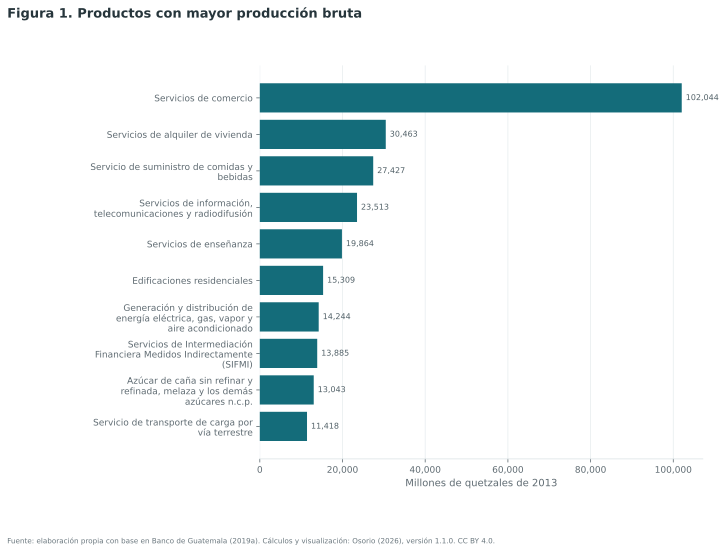

Producto,Producción (Q millones),Participación (%)
Servicios de comercioP102,"102,043.64",14.68
Servicios de alquiler de viviendaP118,"30,462.77",4.38
Servicio de suministro de comidas y bebidasP111,"27,427.27",3.95
"Servicios de información, telecomunicaciones y radiodifusiónP112","23,512.79",3.38
Servicios de enseñanzaP142,"19,863.94",2.86
Edificaciones residencialesP098,"15,309.24",2.20
"Generación y distribución de energía eléctrica, gas, vapor y aire acondicionadoP095","14,244.33",2.05
Servicios de Intermediación Financiera Medidos Indirectamente (SIFMI)P115,"13,885.11",2.00
"Azúcar de caña sin refinar y refinada, melaza y los demás azúcares n.c.p.P052","13,042.76",1.88
Servicio de transporte de carga por vía terrestreP105,"11,417.86",1.64


In [2]:
#@title { display-mode: "form" }
produccion_total = float(x.sum())
consumo_domestico_total = float(Z_d.sum())
consumo_importado_total = float(Z_m.sum())
vab_total = float((coef_vab * x).sum())
empleo_total = float(puestos.sum())

mostrar_tabla_indicadores([
    ("Producción bruta", fmt_num(produccion_total, 2), "Q millones"),
    ("Consumo intermedio nacional", fmt_num(consumo_domestico_total, 2), "Q millones"),
    ("Consumo intermedio importado", fmt_num(consumo_importado_total, 2), "Q millones"),
    ("Valor agregado bruto", fmt_num(vab_total, 2), "Q millones"),
    ("Puestos de trabajo asociados", fmt_entero(empleo_total), "puestos"),
], "Tabla 1. Magnitudes agregadas de la MIP producto por producto", "Totales de la MIP de Guatemala, año de referencia 2013.")

tabla_produccion = produccion[["codigo", "producto", "produccion_precios_basicos"]].rename(
    columns={"produccion_precios_basicos": "produccion"}
)
tabla_produccion["participacion"] = 100 * tabla_produccion["produccion"] / produccion_total
principales_produccion = tabla_produccion.nlargest(12, "produccion")
fig = figura_produccion(principales_produccion.head(10))
mostrar_figura(fig, "Figura 1. Productos con mayor producción bruta")
mostrar_tabla_productos(
    principales_produccion,
    ["produccion", "participacion"],
    ["Producción (Q millones)", "Participación (%)"],
    [2, 2],
    "Tabla 2. Productos con mayor producción bruta",
    "Doce productos con mayor producción bruta.",
    12,
)

## 2. Insumos domésticos e importados

Cada columna de la MIP describe los insumos necesarios para producir el producto correspondiente; cada fila identifica el producto suministrado como insumo. La matriz doméstica registra compras a productores del país y la matriz importada registra insumos intermedios adquiridos al resto del mundo (Banco de Guatemala, 2019b).

Para cada origen $r\in\{d,m\}$ —nacional o importado— el coeficiente se calcula como:

$$
a^{r}_{ij}=
\begin{cases}
z^{r}_{ij}/x_j, & \text{si } x_j>0,\\
0, & \text{si } x_j=0.
\end{cases}
$$

El coeficiente $a_{ij}$ mide el requerimiento directo del insumo $i$ por unidad de producción del producto $j$ (Leontief, 1936; Miller y Blair, 2022). La segunda regla conserva las seis columnas sin producción observada sin dividir por cero. Esos productos se excluyen del selector de escenarios. La participación importada se define, cuando el consumo intermedio es positivo, como:

$$
s^{m}_{j}=
\frac{\sum_i z^{m}_{ij}}
{\sum_i\left(z^{d}_{ij}+z^{m}_{ij}\right)}\times 100.
$$

La figura de composición compara los productos con mayor utilización de insumos. Una participación importada elevada indica dependencia de insumos externos, no necesariamente dependencia de importaciones del producto final.

El **mapa de calor interactivo** cruza los 18 insumos con mayores ventas intermedias y los 18 productos con mayor uso de insumos. Las filas son insumos proveedores; las columnas son productos usuarios. El selector permite alternar coeficientes totales, domésticos e importados sin cambiar el conjunto comparado.

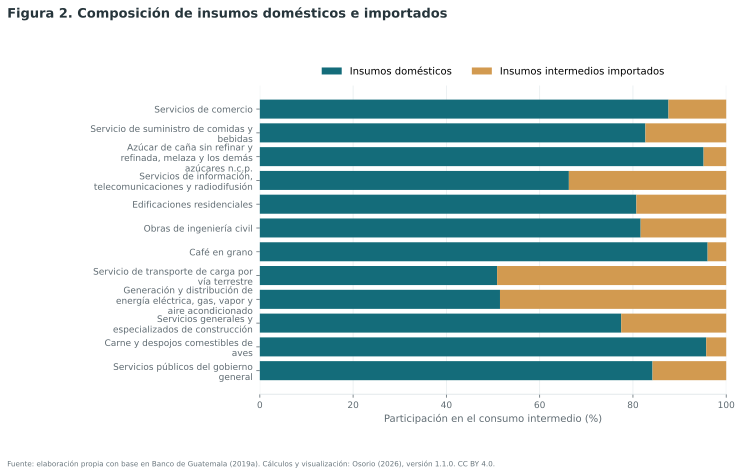

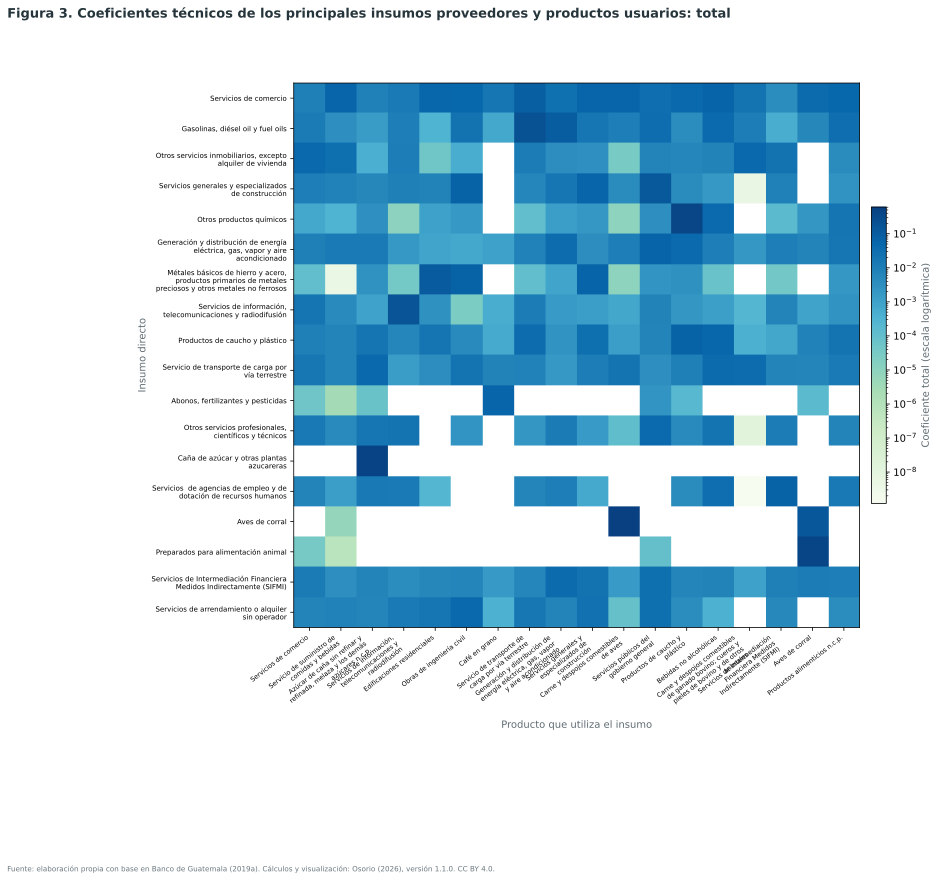

Producto,Insumos domésticos,Insumos intermedios importados,Participación importada (%)
Harina de trigoP047,413.48,"1,209.51",74.52
Productos metálicos estructurales y sus partes de hierro o de aceroP083,280.84,808.51,74.22
Otros productos elaborados de metalP084,491.83,"1,193.13",70.81
Productos de caucho y plásticoP076,"1,728.99","3,758.95",68.49
"Jabón, preparados de limpieza, perfumes y preparados de toiletP073",884.27,"1,513.64",63.12
"Maquinaria para usos generales y especiales, sus partes y piezas, excepto electrodomésticosP085",454.21,675.37,59.79
"Métales básicos de hierro y acero, productos primarios de metales preciosos y otros metales no ferrososP082","1,444.30","2,087.43",59.11
Pasta de papel y papelP064,515.67,704.05,57.72
Envases de papel y cartónP065,797.29,"1,062.33",57.13
Preparados para alimentación animalP054,"1,948.50","2,451.85",55.72


In [3]:
#@title { display-mode: "form" }
estructura = pd.DataFrame({
    "codigo": CODIGOS,
    "producto": [NOMBRES[c] for c in CODIGOS],
    "domestico": Z_d.sum(axis=0),
    "importado": Z_m.sum(axis=0),
})
estructura["total"] = estructura["domestico"] + estructura["importado"]
estructura["participacion_importada"] = np.divide(
    100 * estructura["importado"],
    estructura["total"],
    out=np.full(len(estructura), np.nan),
    where=estructura["total"].to_numpy() > 0,
)
principales_insumos = estructura.nlargest(12, "total")
fig = figura_insumos(principales_insumos, participaciones=True)
mostrar_figura(fig, "Figura 2. Composición de insumos domésticos e importados")

fig_mapa, titulo_mapa = figura_mapa_calor()
mostrar_figura(fig_mapa, titulo_mapa)

umbral = estructura.loc[estructura["total"] > 0, "total"].median()
dependencia = estructura.loc[estructura["total"] >= umbral].nlargest(12, "participacion_importada")
mostrar_tabla_productos(
    dependencia,
    ["domestico", "importado", "participacion_importada"],
    ["Insumos domésticos", "Insumos intermedios importados", "Participación importada (%)"],
    [2, 2, 2],
    "Tabla 3. Productos con mayor participación de insumos intermedios importados",
    "Productos con mayor participación importada entre aquellos cuyo consumo intermedio es igual o superior a la mediana positiva.",
    12,
)

## 3. Encadenamientos productivos

La **inversa de Leontief** resume la producción directa e indirecta necesaria para satisfacer una unidad adicional de demanda final (Leontief, 1936; Miller y Blair, 2022).

$$
\mathbf{L}^{d}=\left(\mathbf{I}-\mathbf{A}^{d}\right)^{-1}
$$

El **índice de poder de dispersión de P. Nørregaard Rasmussen** —encadenamiento hacia atrás— compara la intensidad de los requerimientos de cada producto con el promedio de la MIP. El **índice de sensibilidad de dispersión de Rasmussen** —encadenamiento hacia adelante— compara cuánto aparece cada producto en las respuestas del sistema. En conjunto se conocen como índices de encadenamiento de Rasmussen–Hirschman, por Rasmussen y Albert O. Hirschman (Rasmussen, 1956; Hirschman, 1958; Miller y Blair, 2022).

$$
BL_j=\frac{\frac{1}{n}\sum_i l_{ij}}
{\frac{1}{n^2}\sum_i\sum_j l_{ij}}
$$

$$
FL_i=\frac{\frac{1}{n}\sum_j l_{ij}}
{\frac{1}{n^2}\sum_i\sum_j l_{ij}}
$$

Los valores superiores a 1 indican una intensidad mayor que el promedio. Estos índices describen la estructura de la MIP; no son efectos causales ni recomendaciones de política.

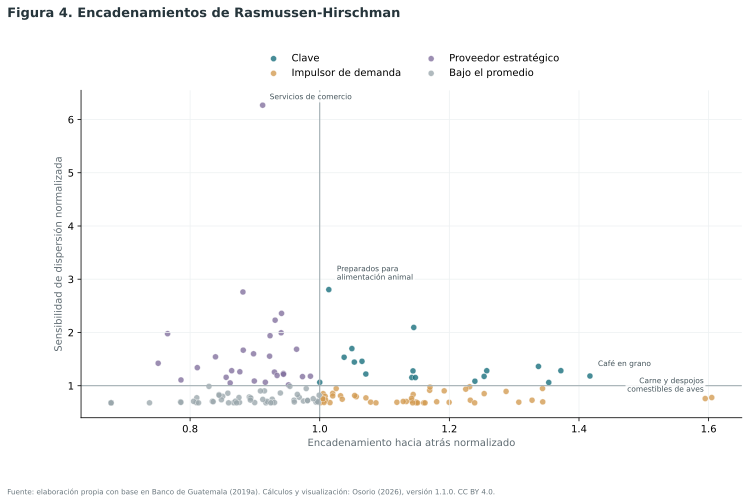

Mayor arrastre,Índice,Mayor sensibilidad de dispersión,Índice
Carne y despojos comestibles de avesP036,1.605,Servicios de comercioP102,6.269
Carne y despojos comestibles de ganado porcinoP035,1.595,Preparados para alimentación animalP054,2.805
Café en granoP016,1.417,"Generación y distribución de energía eléctrica, gas, vapor y aire acondicionadoP095",2.760
"Azúcar de caña sin refinar y refinada, melaza y los demás azúcares n.c.p.P052",1.372,"Otros servicios inmobiliarios, excepto alquiler de viviendaP119",2.359
Caucho naturalP018,1.353,Servicio de transporte de carga por vía terrestreP105,2.231
Leche líquida y crema procesadaP045,1.344,Servicios generales y especializados de construcciónP101,2.094
Carne y despojos comestibles de ganado bovino; cueros y pieles de bovino y de otros animalesP034,1.344,"Abonos, fertilizantes y pesticidasP071",1.994
Aves de corralP023,1.337,Servicios de agencias de empleo y de dotación de recursos humanosP126,1.977
Carne y despojos de otros animales y conservas y preparados de carneP037,1.328,"Otros servicios profesionales, científicos y técnicosP123",1.939
Otros productos lácteos n.c.p.P046,1.307,"Servicios de mantenimiento, reparación e instalación de productos metálicos elaborados, maquinaria y equipoP132",1.697


In [4]:
#@title { display-mode: "form" }
fig = figura_encadenamientos(indicadores)
mostrar_figura(fig, "Figura 4. Encadenamientos de Rasmussen-Hirschman")

ranking_atras = indicadores.nlargest(10, "encadenamiento_atras_normalizado")
ranking_adelante = indicadores.nlargest(10, "indice_dispersion_adelante_rh_normalizado")
mostrar_tabla_rankings(ranking_atras, ranking_adelante)

## Producto y escenario de consulta

Seleccione un producto por su nombre. El mismo selector actualiza la estructura de insumos y la simulación. El monto representa un aumento de demanda final de producción doméstica, expresado en millones de quetzales de 2013.

Los identificadores `P001`–`P152` corresponden a la **Nomenclatura de Productos de Guatemala (NPG)** agregada para la publicación de la MIP. Se muestran como referencia secundaria y siempre acompañados por el nombre oficial del producto (Banco de Guatemala, 2019c).

In [5]:
#@title { display-mode: "form" }
PRODUCTO_INICIAL = "P102"
MONTO_INICIAL = 100.0

if HAY_WIDGETS:
    try:
        from google.colab import output as _colab_output
        _colab_output.enable_custom_widget_manager()
    except ImportError:
        pass
    selector_producto = widgets.Dropdown(
        options=[(titulo_producto(codigo), codigo) for codigo in CODIGOS_SIMULABLES],
        value=PRODUCTO_INICIAL,
        description="Producto",
        layout=widgets.Layout(width="100%", max_width="820px"),
        style={"description_width": "80px"},
    )
    monto_choque = widgets.BoundedFloatText(
        value=MONTO_INICIAL,
        min=0.01,
        max=1_000_000,
        step=10.0,
        description="Monto",
        layout=widgets.Layout(width="100%", max_width="340px"),
        style={"description_width": "80px"},
    )
    unidad_monto = widgets.HTML("<span style='font-family:Arial,sans-serif;color:#6f7b81;font-size:12px'>Q millones de 2013</span>")
    _display(widgets.VBox([selector_producto, widgets.HBox([monto_choque, unidad_monto])]))
else:
    selector_producto = PRODUCTO_INICIAL
    monto_choque = MONTO_INICIAL
    _display(_HTML(
        '<div style="font-family:Arial,sans-serif;border:1px solid #d4dfe2;border-radius:8px;padding:12px 14px;color:#334148">'
        + '<strong>Producto:</strong> ' + _html.escape(titulo_producto(PRODUCTO_INICIAL))
        + '<br><strong>Monto:</strong> Q 100 millones de 2013</div>'
    ))

## 4. Estructura del producto seleccionado

La vista muestra el tamaño del producto, sus multiplicadores y sus principales insumos directos. Los coeficientes indican cuántos quetzales de insumos domésticos o importados se requieren por cada quetzal de producción; los multiplicadores combinan requerimientos directos e indirectos (Miller y Blair, 2022).

Indicador,Valor,Unidad
Producción,"102,043.64",Q millones
Multiplicador de producción doméstica,1.345,Q por Q de demanda final
Requerimiento total de insumos intermedios importados,0.072,Q por Q de demanda final
Valor agregado asociado,0.917,Q por Q de demanda final
Empleo asociado,13.14,puestos por Q1 millón


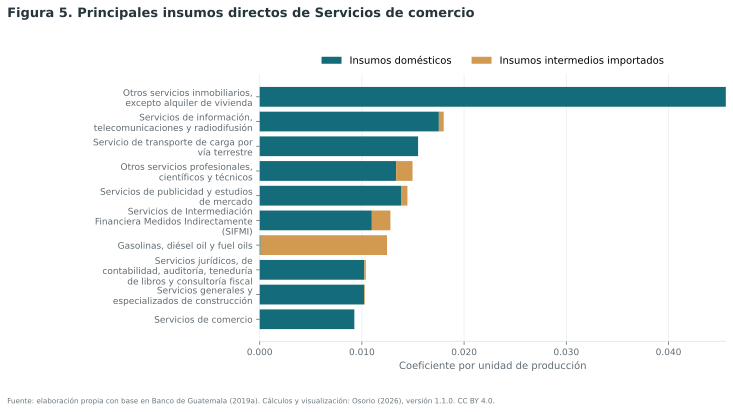

Producto,Coeficiente doméstico,Coeficiente importado,Coeficiente total
"Otros servicios inmobiliarios, excepto alquiler de viviendaP119",0.0456,0.0000,0.0456
"Servicios de información, telecomunicaciones y radiodifusiónP112",0.0175,0.0005,0.0180
Servicio de transporte de carga por vía terrestreP105,0.0155,0.0000,0.0155
"Otros servicios profesionales, científicos y técnicosP123",0.0134,0.0016,0.0150
Servicios de publicidad y estudios de mercadoP124,0.0138,0.0006,0.0145
Servicios de Intermediación Financiera Medidos Indirectamente (SIFMI)P115,0.0110,0.0018,0.0128
"Gasolinas, diésel oil y fuel oilsP068",0.0001,0.0124,0.0125
"Servicios jurídicos, de contabilidad, auditoría, teneduría de libros y consultoría fiscalP120",0.0102,0.0001,0.0104
Servicios generales y especializados de construcciónP101,0.0102,0.0001,0.0103
Servicios de comercioP102,0.0093,0.0000,0.0093


In [6]:
#@title { display-mode: "form" }
if HAY_WIDGETS:
    salida_producto = widgets.Output()
    def actualizar_producto(cambio=None):
        with salida_producto:
            _clear_output(wait=True)
            mostrar_producto(selector_producto.value)
    selector_producto.observe(actualizar_producto, names="value")
    actualizar_producto()
    _display(salida_producto)
else:
    mostrar_producto(PRODUCTO_INICIAL)

## 5. Simulación de un aumento de demanda final

El escenario introduce un aumento exógeno en la demanda final de producción doméstica del producto seleccionado. El modelo mantiene constantes los precios, la tecnología y los coeficientes de 2013. Las importaciones estimadas corresponden solo a insumos intermedios; no incluyen compras externas destinadas directamente a la demanda final (Leontief, 1936; Banco de Guatemala, 2019b; Miller y Blair, 2022).

$$
\Delta\mathbf{x}=\mathbf{L}^{d}\Delta\mathbf{f}
$$

$$
\Delta\mathbf{m}=\mathbf{A}^{m}\Delta\mathbf{x}
$$

$$
\Delta M=\mathbf{1}^{\top}\Delta\mathbf{m}
$$

$$
\Delta\mathbf{v}=\operatorname{diag}(\mathbf{a}_{v})\Delta\mathbf{x}
$$

$$
\Delta\mathbf{e}=\operatorname{diag}(\mathbf{a}_{e})\Delta\mathbf{x}
$$

La producción directa corresponde al aumento inicial de demanda. La producción indirecta recoge los requerimientos adicionales transmitidos a otros productos. Los vectores $\Delta\mathbf{m}$, $\Delta\mathbf{v}$ y $\Delta\mathbf{e}$ distribuyen los resultados por producto; las tablas presentan sus sumas y su composición. En la figura interactiva puede alternarse entre producción, insumos intermedios importados, VAB y puestos asociados sin mezclar unidades.

Indicador,Valor,Unidad
Producción directa,100.00,Q millones
Producción indirecta,34.49,Q millones
Producción doméstica total,134.49,Q millones
Insumos intermedios importados asociados,7.21,Q millones
Valor agregado asociado,91.73,Q millones
Empleo asociado,"1,313.89",puestos


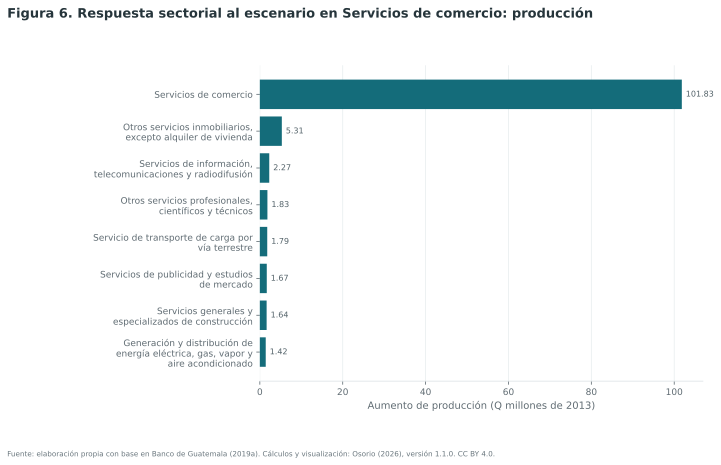

Producto,Producción,Importaciones intermedias del producto,VAB,Puestos
Servicios de comercioP102,101.833,0.000,72.504,"1,136.29"
"Otros servicios inmobiliarios, excepto alquiler de viviendaP119",5.307,0.000,3.771,20.53
"Servicios de información, telecomunicaciones y radiodifusiónP112",2.272,0.219,1.436,2.49
"Otros servicios profesionales, científicos y técnicosP123",1.829,0.182,1.277,10.53
Servicio de transporte de carga por vía terrestreP105,1.786,0.000,0.782,14.23
Servicios de publicidad y estudios de mercadoP124,1.674,0.068,0.884,5.66
Servicios generales y especializados de construcciónP101,1.639,0.017,0.641,8.89
"Generación y distribución de energía eléctrica, gas, vapor y aire acondicionadoP095",1.423,0.000,0.818,1.01
"Servicios jurídicos, de contabilidad, auditoría, teneduría de libros y consultoría fiscalP120",1.367,0.016,1.094,9.98
Servicios de Intermediación Financiera Medidos Indirectamente (SIFMI)P115,1.341,0.225,0.890,2.96


In [7]:
#@title { display-mode: "form" }
if HAY_WIDGETS:
    salida_simulacion = widgets.Output()
    def actualizar_simulacion(cambio=None):
        with salida_simulacion:
            _clear_output(wait=True)
            mostrar_simulacion(selector_producto.value, monto_choque.value)
    selector_producto.observe(actualizar_simulacion, names="value")
    monto_choque.observe(actualizar_simulacion, names="value")
    actualizar_simulacion()
    _display(salida_simulacion)
else:
    mostrar_simulacion(PRODUCTO_INICIAL, MONTO_INICIAL)

## Claves de interpretación y reutilización

- La MIP representa la estructura económica del año de referencia 2013; no es una predicción de la tecnología actual (Banco de Guatemala, 2019b).
- Los multiplicadores suponen coeficientes fijos, precios constantes, capacidad productiva suficiente y ausencia de sustitución entre insumos (Miller y Blair, 2022).
- Las importaciones corresponden a insumos intermedios asociados con la producción doméstica; no deben sumarse a la producción nacional.
- El valor agregado es el resultado macroeconómico primario del modelo. El campo legado rotulado como producto interno bruto no se utiliza en las simulaciones.
- El empleo se interpreta como puestos asociados con los coeficientes medios de 2013, no como empleo neto creado.
- Los productos sin producción observada se conservan en la MIP por completitud contable, pero no aparecen en el selector de escenarios.

Para reutilizar esta MIP, documente el producto seleccionado, el monto y la unidad del choque, la fecha de consulta, cualquier concordancia utilizada y la versión empleada. La metodología completa, el diccionario y los resultados descargables se encuentran en las carpetas `01_metodologia` y `02_resultados_y_diccionario` del repositorio.

## Cómo citar este conjunto de datos y cuaderno

**Cita dentro del texto:** (Osorio, 2026).

**Referencia completa de la versión archivada:**

> Osorio, J. A. (2026). *MIP Guatemala 2013 reproducible* (versión 1.1.0) [Conjunto de datos, código y cuaderno]. Zenodo. https://doi.org/10.5281/zenodo.22089741

El DOI anterior corresponde a la versión 1.1.0 reservada para publicación; mientras este cuaderno permanezca en revisión, cite además el repositorio y el commit consultado. Al reutilizar una cifra, tabla o visualización, cite tanto a Osorio (2026) por los cálculos como al Banco de Guatemala (2019a, 2019b) por la fuente estadística.

## Referencias

- Banco de Guatemala. (2019a). *Matriz Insumo-Producto (MIP), año de referencia 2013: MIP producto por producto* [Archivo de Excel]. https://banguat.gob.gt/sites/default/files/banguat/Publica/IMAE/2013/MIP/MIP_AR2013_NPG.xlsx
- Banco de Guatemala. (2019b). *Matriz Insumo-Producto (MIP): En el marco del cambio de año de referencia 2013 y adopción del SCN 2008. Aspectos conceptuales y metodológicos*. https://banguat.gob.gt/sites/default/files/banguat/Publica/IMAE/2013/MIP/Metodologia_MIP_AR2013.pdf
- Banco de Guatemala. (2019c). *Cuentas Nacionales de Guatemala. Año de referencia 2013: aspectos conceptuales, metodológicos y fuentes de información*. https://banguat.gob.gt/sites/default/files/banguat/cuentasnac/PIB2013/Cuentas_nacionales_de_Guatemala_aspectos_conceptuales_metodologicos.pdf
- Comisión Europea, Fondo Monetario Internacional, Organización de Cooperación y Desarrollo Económicos, Naciones Unidas y Banco Mundial. (2016). *Sistema de Cuentas Nacionales 2008*. Naciones Unidas. https://unstats.un.org/unsd/nationalaccount/docs/SNA2008Spanish.pdf
- Hirschman, A. O. (1958). *The strategy of economic development*. Yale University Press.
- Leontief, W. W. (1936). Quantitative input and output relations in the economic systems of the United States. *The Review of Economics and Statistics, 18*(3), 105–125. https://doi.org/10.2307/1927837
- Miller, R. E. y Blair, P. D. (2022). *Input-output analysis: Foundations and extensions* (3.ª ed.). Cambridge University Press. https://doi.org/10.1017/9781108676212
- Plotly Technologies Inc. (2015). *Collaborative data science*. Montréal, Canadá. https://plotly.com/python/
- Rasmussen, P. N. (1956). *Studies in inter-sectoral relations*. Einar Harcks; North-Holland.